## Import Libraries

In [1]:
! pip install datasets
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 53.2 MB/s eta 0:00:00


In [52]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import huggingface_hub
import transformers
import datasets
import numpy as np
from pathlib import Path
from datasets import load_dataset,Dataset
from transformers import AutoTokenizer
from transformers import pipeline
import random
from rdkit import Chem
from rdkit.Chem import Draw
from google.colab import files

#import os
#os.environ['WANDB_DISABLED'] = 'true'

In [3]:
def tokenize(batch):
  return tokenizer(batch["text"], padding=True, truncation=True, max_length=250, return_special_tokens_mask=True)

## Sign in to HF hub

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

## Set up model

In [4]:
model_name = "cafierom/bert-base-cased-DA-ChemTok-ZN1540K-V1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(model_name,padding = True, truncation = True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/3.10k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/671k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/196 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

## read in dataset and tokenize

In [5]:
ic50s = load_dataset("csv", data_files="/content/905-unique-statins.csv", sep=",",names=["index","text","value"])

Generating train split: 0 examples [00:00, ? examples/s]

## Configure un-masking model pipeline

In [6]:
mask_filler = pipeline("fill-mask", model_name)

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


generation_config.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

Device set to use cpu


## Gen by unmasking many tokens

In [7]:
def gen_from_multimask(text, print_flag=True, mask_flag="random", percent = 0.10, top_k = 3):
  new_tok_list = []
  single_tok = tokenizer(text, padding=True, truncation=True, max_length=250, return_special_tokens_mask=True)
  length_count = 0
  for token in single_tok["input_ids"]:
    if token != 0:
      length_count += 1

  if mask_flag == "last":
    masked_tokens = [*range(int(length_count*(1.0-percent))-1,length_count-1)]
  elif mask_flag == "first":
    masked_tokens = [*range(0,int(length_count*percent))]
  elif mask_flag == "random":
    masked_tokens = random.sample(range(1, length_count), int(length_count*percent))

  for j,token in enumerate(single_tok["input_ids"]):
    if token != 0:
      if j in masked_tokens:
        new_tok_list.append(103)
      else:
        new_tok_list.append(token)
  masked_smile = tokenizer.decode(new_tok_list,
                    skip_special_tokens=False).replace("[PAD]","").replace("[SEP]","").replace("[CLS]","").replace(" ","")
  result = mask_filler(masked_smile,top_k=top_k)

  new_smiles = []
  total_batch = []

  for i in range(len(result)):

    batch_smiles = []

    for j in range(top_k):

      if result[i][j]["score"] > 0.1:
        if i == 0:
          new_smile = result[i][j]["sequence"].replace(" ","").replace("[SEP]","").replace("[CLS]","")
          batch_smiles.append(new_smile)
        else:
          for smile in total_batch[i-1]:
            new_smile = smile.replace("[MASK]",result[i][j]["token_str"],1)
            batch_smiles.append(new_smile)

    total_batch.append(batch_smiles)

  final_smiles = []
  for smile in total_batch[-1]:
      new_smile = smile.replace("##","")
      final_smiles.append(new_smile)

  if print_flag:
    print(f"original:    {text}")
    final_smiles.insert(0,text)
    for smile in final_smiles:
      print(f"generated:   {smile}")

  return final_smiles

In [8]:
knowns_list = []
for statin in ic50s["train"]["text"]:
  knowns_list.append(statin)

# for statin in ic50s['test']["text"]:
#   knowns_list.append(statin)

print(f"Dataset has {len(knowns_list)} statins")

Dataset has 906 statins


In [66]:
how_many_statins = 1
which_statins = random.sample(range(len(knowns_list)), how_many_statins)
print(f"Using statins: {which_statins} with IC50 {ic50s['train']['value'][which_statins[0]]}")

Using statins: [877] with IC50  17


In [67]:
main_smiles = []

for statin in which_statins:
  result = gen_from_multimask(knowns_list[statin], print_flag=False, mask_flag = "first", percent=0.15)
  for smile in result:
    if smile not in main_smiles:
      main_smiles.append(smile)
  length = len(main_smiles)
  print(f"First masking generated {length} SMILES")

  result = gen_from_multimask(knowns_list[statin], print_flag=False, mask_flag = "last", percent=0.15)
  for smile in result:
    if smile not in main_smiles:
      main_smiles.append(smile)
  print(f"Last masking generated {len(main_smiles)-length} SMILES")
  length = len(main_smiles)

  for _ in range(4):
    result = gen_from_multimask(knowns_list[statin], print_flag=False, mask_flag = "random", percent=0.15)
    for smile in result:
      if smile not in main_smiles:
        main_smiles.append(smile)
    print(f"Random masking generated {len(main_smiles)-length} SMILES")
    length = len(main_smiles)

print(f"Total SMILES generated: {len(main_smiles)}")

First masking generated 108 SMILES
Last masking generated 108 SMILES
Random masking generated 16 SMILES
Random masking generated 6 SMILES
Random masking generated 2 SMILES
Random masking generated 12 SMILES
Total SMILES generated: 252


In [68]:
print(f"Total SMILES generated: {len(main_smiles)}")
main_smiles = list(set(main_smiles))
print(f"Total SMILES generated after removing duplicates: {len(main_smiles)}")

Total SMILES generated: 252
Total SMILES generated after removing duplicates: 252


In [69]:
mols = []
valid_smiles = []
for smile in main_smiles:
  try:
    mol = Chem.MolFromSmiles(smile)
    if mol is not None:
      mols.append(mol)
      valid_smiles.append(smile)
  except:
    print("Could not convert to mol")

print(f"Total SMILES after removing invalid molecules: {len(valid_smiles)}")

Total SMILES after removing invalid molecules: 17


[17:05:21] SMILES Parse Error: syntax error while parsing: CC(C)c1c(OC[C@@H](O)C[C@@H](O)CC(O)=O)n(nc1C(=O)NCc1ccccc1C)[(=O)CCC=C
[17:05:21] SMILES Parse Error: check for mistakes around position 62:
[17:05:21] c1C(=O)NCc1ccccc1C)[(=O)CCC=C
[17:05:21] ~~~~~~~~~~~~~~~~~~~~^
[17:05:21] SMILES Parse Error: Failed parsing SMILES 'CC(C)c1c(OC[C@@H](O)C[C@@H](O)CC(O)=O)n(nc1C(=O)NCc1ccccc1C)[(=O)CCC=C' for input: 'CC(C)c1c(OC[C@@H](O)C[C@@H](O)CC(O)=O)n(nc1C(=O)NCc1ccccc1C)[(=O)CCC=C'
[17:05:21] SMILES Parse Error: syntax error while parsing: CC(C)c1c(OC[C@@H](O)C[C@@H](O)CC(O)=O)n(nc1C(=O)NCc1ccccc1C)c1[CCC(=O)C
[17:05:21] SMILES Parse Error: check for mistakes around position 65:
[17:05:21] (=O)NCc1ccccc1C)c1[CCC(=O)C
[17:05:21] ~~~~~~~~~~~~~~~~~~~~^
[17:05:21] SMILES Parse Error: Failed parsing SMILES 'CC(C)c1c(OC[C@@H](O)C[C@@H](O)CC(O)=O)n(nc1C(=O)NCc1ccccc1C)c1[CCC(=O)C' for input: 'CC(C)c1c(OC[C@@H](O)C[C@@H](O)CC(O)=O)n(nc1C(=O)NCc1ccccc1C)c1[CCC(=O)C'
[17:05:21] SMILES Parse Error: 

In [37]:
valid_knowns = []
for smile in knowns_list:
  try:
    mol = Chem.MolFromSmiles(smile)
    if mol is not None:
      valid_knowns.append(smile)
  except:
    print("Could not convert to mol")

print(f"Total known SMILES after removing invalid molecules: {len(valid_knowns)}")

[16:31:56] SMILES Parse Error: syntax error while parsing: Ligand
[16:31:56] SMILES Parse Error: check for mistakes around position 1:
[16:31:56] Ligand
[16:31:56] ^
[16:31:56] SMILES Parse Error: Failed parsing SMILES 'Ligand' for input: 'Ligand'


Total known SMILES after removing invalid molecules: 905


In [70]:
unique_smiles = []

canon_smiles = [Chem.CanonSmiles(smile) for smile in valid_smiles]
canon_knowns = [Chem.CanonSmiles(smile) for smile in valid_knowns]

for smile in canon_smiles:
  if smile not in canon_knowns:
    unique_smiles.append(smile)

print(f"Total unique SMILES generated: {len(unique_smiles)}")

Total unique SMILES generated: 17


In [71]:
dict_smiles =  unique_smiles
dict_smiles.insert(0,knowns_list[which_statins[0]])
dict = {"smiles":dict_smiles}
df = pd.DataFrame(dict)
filename = f"statin{which_statins[0]}fullgen15p"
df.to_csv(filename+".csv")
files.download(filename+".csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Visualize generated molecules

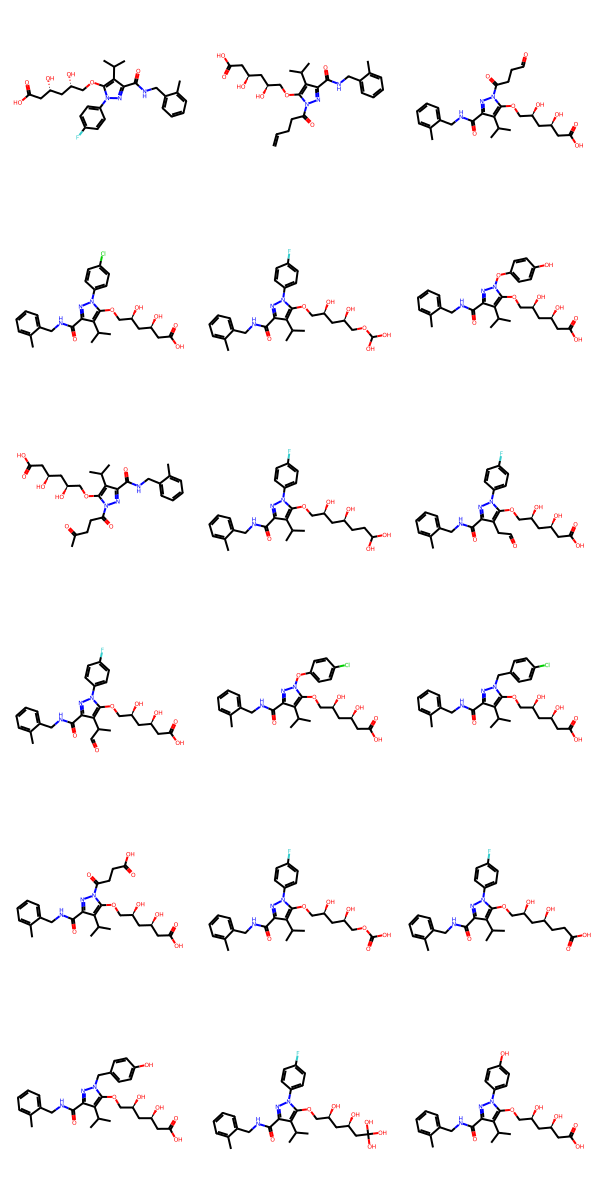

In [72]:
mols = [Chem.MolFromSmiles(smile) for smile in dict_smiles]
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(200,200))

In [73]:
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(200,200))
pic = img.data

with open(filename+".png",'wb+') as outf:
    outf.write(pic)

files.download(filename+".png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>